# Optimización: 2_Mom_Reversal Exit

Misma entrada (11_Strong_Momentum, rolling P75/P25, N=500).  
Optimizamos los parámetros de la salida Momentum Reversal.

### Parámetros a optimizar

| Parámetro | Qué controla | Rango |
|-----------|-------------|-------|
| **margin** | Cuánto tiene que cruzar cero en contra para salir | 0.0 → 0.001 |
| **min_progress** | No salir antes de este % del mercado (evitar exits prematuros) | 0.0 → 0.50 |
| **confirm_snaps** | Nº de snapshots consecutivos en contra antes de salir | 1 → 3 |

### Metodología
1. Grid search sobre los 3 parámetros en test set
2. Top 10 combinaciones por ROI
3. Monte Carlo de las top 3 para robustez
4. Análisis de sensibilidad de cada parámetro

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from itertools import product

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

CFG = dict(
    DATA_PATH      = '../dataset_with_resolution.csv',
    STAKE          = 10.0,
    INIT_CAPITAL   = 100.0,
    ENTRY_LO       = 0.10,
    ENTRY_HI       = 0.60,
    TRAIN_FRAC     = 0.40,
    VAL_FRAC       = 0.15,
    PERCENTILE     = 75,
    ROLLING_WINDOW = 500,
)

# ── Grid de parámetros ────────────────────────────────────────────────
GRID = dict(
    margin        = [0.0, 0.00005, 0.0001, 0.0002, 0.0003, 0.0005, 0.001],
    min_progress  = [0.0, 0.15, 0.25, 0.35, 0.45],
    confirm_snaps = [1, 2, 3],
)

total_combos = 1
for v in GRID.values():
    total_combos *= len(v)

print("Configuración:")
for k, v in CFG.items():
    print(f"  {k:<18} = {v}")
print(f"\nGrid: {total_combos} combinaciones")
for k, v in GRID.items():
    print(f"  {k:<18} = {v}")

Configuración:
  DATA_PATH          = ../dataset_with_resolution.csv
  STAKE              = 10.0
  INIT_CAPITAL       = 100.0
  ENTRY_LO           = 0.1
  ENTRY_HI           = 0.6
  TRAIN_FRAC         = 0.4
  VAL_FRAC           = 0.15
  PERCENTILE         = 75
  ROLLING_WINDOW     = 500

Grid: 105 combinaciones
  margin             = [0.0, 5e-05, 0.0001, 0.0002, 0.0003, 0.0005, 0.001]
  min_progress       = [0.0, 0.15, 0.25, 0.35, 0.45]
  confirm_snaps      = [1, 2, 3]


---
## 1 · Carga y Preparación

In [2]:
df = pd.read_csv(CFG['DATA_PATH'], parse_dates=['timestamp'])
if df['timestamp'].dt.tz is None:
    df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
else:
    df['timestamp'] = df['timestamp'].dt.tz_convert('UTC')
df = df.sort_values(['timestamp', 'market_slug']).reset_index(drop=True)

res_check = df.groupby('market_slug')['resolution'].nunique()
bad = res_check[res_check > 1].index
if len(bad):
    df = df[~df['market_slug'].isin(bad)]
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
df['market_progress'] = df['market_progress'].clip(0.0, 1.0)
df['vol_ratio'] = df['volatility_3m'] / (df['volatility_5m'] + 1e-9)

market_order = df.groupby('market_slug')['timestamp'].min().sort_values().index.tolist()
N = len(market_order)
n_train = int(N * CFG['TRAIN_FRAC'])
n_val   = int(N * CFG['VAL_FRAC'])
train_m = market_order[:n_train]
test_m  = market_order[n_train + n_val:]

tr = df[df['market_slug'].isin(train_m)].copy()
te = df[df['market_slug'].isin(test_m)].copy()

tr_w = tr[(tr['market_progress'] >= CFG['ENTRY_LO']) & (tr['market_progress'] <= CFG['ENTRY_HI'])]
SEED_UP   = tr_w['btc_return_since_open'].quantile(CFG['PERCENTILE'] / 100)
SEED_DOWN = tr_w['btc_return_since_open'].quantile(1 - CFG['PERCENTILE'] / 100)

print(f"Train: {len(train_m)} mkts | Test: {len(test_m)} mkts")
print(f"Seed thresholds: UP={SEED_UP:+.6f}  DOWN={SEED_DOWN:+.6f}")

Train: 713 mkts | Test: 803 mkts
Seed thresholds: UP=+0.000314  DOWN=-0.000356


---
## 2 · Motor de Backtest

In [3]:
class RollingCalibrator:
    def __init__(self, window_size, percentile, seed_up, seed_down):
        self.buffer = deque(maxlen=window_size)
        self.percentile = percentile
        self.threshold_up = seed_up
        self.threshold_down = seed_down
        self.min_samples = 50

    def feed(self, values):
        for v in values:
            if not np.isnan(v):
                self.buffer.append(v)
        if len(self.buffer) >= self.min_samples:
            arr = np.array(self.buffer)
            self.threshold_up = float(np.percentile(arr, self.percentile))
            self.threshold_down = float(np.percentile(arr, 100 - self.percentile))

    def clone(self):
        """Copia profunda para reutilizar entre iteraciones del grid."""
        c = RollingCalibrator.__new__(RollingCalibrator)
        c.buffer = deque(self.buffer, maxlen=self.buffer.maxlen)
        c.percentile = self.percentile
        c.threshold_up = self.threshold_up
        c.threshold_down = self.threshold_down
        c.min_samples = self.min_samples
        return c


def early_exit_pnl(stake, entry_ask, exit_bid):
    return stake * (exit_bid / entry_ask - 1.0)


def run_backtest_mom_reversal(test_df, cfg, cal_template, margin, min_progress, confirm_snaps):
    """
    Backtest con entrada Strong Momentum + salida Mom Reversal parametrizada.
    
    Exit: si btc_return_since_open cruza contra tu dirección por más de `margin`,
          durante al menos `confirm_snaps` snapshots consecutivos,
          y el mercado ha pasado del `min_progress`.
    """
    STAKE = cfg['STAKE']
    lo, hi = cfg['ENTRY_LO'], cfg['ENTRY_HI']
    cal = cal_template.clone()

    mkt_order = (
        test_df.groupby('market_slug')['timestamp'].min()
        .sort_values().index.tolist()
    )

    trades = []
    for mkt in mkt_order:
        snaps = test_df[test_df['market_slug'] == mkt].sort_values('timestamp')
        window = snaps[(snaps['market_progress'] >= lo) & (snaps['market_progress'] <= hi)]
        op_vals = window['btc_return_since_open'].values

        if window.empty:
            cal.feed(op_vals)
            continue

        t_up = cal.threshold_up
        t_down = cal.threshold_down

        # ── Entrada ──────────────────────────────────────────────────
        entry_row = None
        direction = None
        for _, row in window.iterrows():
            ret = row.get('btc_return_since_open', np.nan)
            if pd.isna(ret):
                continue
            if ret > t_up:
                ask = row.get('up_ask_p_1', np.nan)
                if not pd.isna(ask) and 0 < ask < 1:
                    entry_row = row; direction = 'UP'; break
            elif ret < t_down:
                ask = row.get('down_ask_p_1', np.nan)
                if not pd.isna(ask) and 0 < ask < 1:
                    entry_row = row; direction = 'DOWN'; break

        cal.feed(op_vals)
        if entry_row is None:
            continue

        entry_ask = entry_row['up_ask_p_1'] if direction == 'UP' else entry_row['down_ask_p_1']
        entry_ts = entry_row['timestamp']

        resolution = snaps['resolution'].iloc[0]
        actual_up = (resolution.lower() == 'up')
        won = (actual_up if direction == 'UP' else not actual_up)
        win_net = entry_row['up_win_net'] if direction == 'UP' else entry_row['down_win_net']
        loss_net = entry_row['up_loss_net'] if direction == 'UP' else entry_row['down_loss_net']
        pnl_at_res = win_net if won else loss_net

        # ── Salida: Momentum Reversal parametrizada ──────────────────
        exit_type = 'RESOLUTION'
        exit_pnl = pnl_at_res
        exit_prog = snaps['market_progress'].iloc[-1]

        future = snaps[snaps['timestamp'] > entry_ts]
        bid_col = 'up_bid_p_1' if direction == 'UP' else 'down_bid_p_1'
        consecutive_against = 0

        for _, snap in future.iterrows():
            # No salir antes de min_progress
            prog = snap.get('market_progress', 0)
            if prog < min_progress:
                consecutive_against = 0
                continue

            ret = snap.get('btc_return_since_open', np.nan)
            if pd.isna(ret):
                continue

            # ¿El retorno está en contra?
            against = False
            if direction == 'UP' and ret < -margin:
                against = True
            elif direction == 'DOWN' and ret > margin:
                against = True

            if against:
                consecutive_against += 1
            else:
                consecutive_against = 0

            # ¿Confirmación suficiente?
            if consecutive_against >= confirm_snaps:
                cur_bid = snap.get(bid_col, np.nan)
                if not pd.isna(cur_bid) and cur_bid > 0:
                    exit_type = 'EARLY_EXIT'
                    exit_pnl = early_exit_pnl(STAKE, entry_ask, cur_bid)
                    exit_prog = prog
                    break

        trades.append({
            'timestamp': entry_ts, 'market': mkt,
            'direction': direction, 'resolution': resolution,
            'won_at_resolution': won,
            'entry_progress': entry_row['market_progress'],
            'entry_ask': entry_ask,
            'exit_type': exit_type, 'exit_progress': exit_prog,
            'pnl': exit_pnl, 'pnl_at_resolution': pnl_at_res,
        })

    if not trades:
        return pd.DataFrame(), pd.Series(dtype=float)

    tdf = pd.DataFrame(trades).sort_values('timestamp').reset_index(drop=True)
    tdf['cumulative_pnl'] = tdf['pnl'].cumsum()
    tdf['equity'] = cfg['INIT_CAPITAL'] + tdf['cumulative_pnl']
    equity_s = pd.concat([
        pd.Series([cfg['INIT_CAPITAL']], index=[tdf['timestamp'].iloc[0]]),
        tdf.set_index('timestamp')['equity'],
    ])
    return tdf, equity_s


# Pre-construir calibrador base (train seed)
CAL_BASE = RollingCalibrator(CFG['ROLLING_WINDOW'], CFG['PERCENTILE'], SEED_UP, SEED_DOWN)
train_vals = tr_w['btc_return_since_open'].dropna().values
seed_data = train_vals[-CFG['ROLLING_WINDOW'] * 3:] if len(train_vals) > CFG['ROLLING_WINDOW'] * 3 else train_vals
CAL_BASE.feed(seed_data)

print(f"Calibrador base: UP={CAL_BASE.threshold_up:.6f}  DOWN={CAL_BASE.threshold_down:.6f}")
print("Motor listo.")

Calibrador base: UP=0.000667  DOWN=-0.000357
Motor listo.


---
## 3 · Grid Search

In [4]:
# ═══════════════════════════════════════════════════════════════════════
# 3. GRID SEARCH
# ═══════════════════════════════════════════════════════════════════════
combos = list(product(GRID['margin'], GRID['min_progress'], GRID['confirm_snaps']))
print(f"Ejecutando {len(combos)} combinaciones...\n")

grid_results = []

for idx, (margin, min_prog, confirm) in enumerate(combos):
    tdf, eq_s = run_backtest_mom_reversal(te, CFG, CAL_BASE, margin, min_prog, confirm)

    if tdf.empty:
        grid_results.append(dict(
            margin=margin, min_progress=min_prog, confirm_snaps=confirm,
            n=0, wr=np.nan, pnl=0, roi=0, sharpe=0, mdd=0,
            n_exits=0, exit_pct=0, avg_pnl=0,
        ))
        continue

    n = len(tdf)
    pa = tdf['pnl'].values
    eq = eq_s.values
    rm = np.maximum.accumulate(eq)
    n_exits = (tdf['exit_type'] == 'EARLY_EXIT').sum()

    grid_results.append(dict(
        margin=margin, min_progress=min_prog, confirm_snaps=confirm,
        n=n,
        wr=(pa > 0).mean(),
        pnl=pa.sum(),
        roi=pa.sum() / CFG['INIT_CAPITAL'],
        sharpe=pa.mean() / (pa.std() + 1e-9) * np.sqrt(n),
        mdd=((eq - rm) / rm).min(),
        n_exits=n_exits,
        exit_pct=n_exits / n,
        avg_pnl=pa.mean(),
    ))

    if (idx + 1) % 20 == 0:
        print(f"  {idx+1}/{len(combos)} completadas...")

grid_df = pd.DataFrame(grid_results)
print(f"\n✅ Grid completada: {len(grid_df)} combinaciones")
print(f"   Con trades: {(grid_df['n'] > 0).sum()}")

Ejecutando 105 combinaciones...

  20/105 completadas...
  40/105 completadas...
  60/105 completadas...
  80/105 completadas...
  100/105 completadas...

✅ Grid completada: 105 combinaciones
   Con trades: 105


---
## 4 · Top 10 + Baseline

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# 4. TOP 10 POR ROI
# ═══════════════════════════════════════════════════════════════════════

# Baseline: Hold (margin y min_progress no importan → no hay exit)
# Es la fila con confirm_snaps más alto y margin más alto (nunca sale)
# Más fácil: correrlo directamente
tdf_hold, eq_hold = run_backtest_mom_reversal(te, CFG, CAL_BASE,
                                               margin=999, min_progress=0, confirm_snaps=1)
pa_hold = tdf_hold['pnl'].values
eq_h = eq_hold.values
rm_h = np.maximum.accumulate(eq_h)
hold_stats = dict(
    margin='HOLD', min_progress='-', confirm_snaps='-',
    n=len(tdf_hold), wr=(pa_hold > 0).mean(),
    pnl=pa_hold.sum(), roi=pa_hold.sum()/CFG['INIT_CAPITAL'],
    sharpe=pa_hold.mean()/(pa_hold.std()+1e-9)*np.sqrt(len(tdf_hold)),
    mdd=((eq_h-rm_h)/rm_h).min(), n_exits=0, exit_pct=0, avg_pnl=pa_hold.mean(),
)

top10 = grid_df[grid_df['n'] > 0].sort_values('roi', ascending=False).head(10)

print("TOP 10 COMBINACIONES POR ROI + BASELINE")
print("═" * 115)
print(f"{'Rk':>3} {'margin':>9} {'min_prog':>9} {'conf':>5} │ "
      f"{'N':>5} {'WR':>6} {'PnL(€)':>9} {'ROI':>8} {'Sharpe':>7} "
      f"{'MDD':>8} {'Exits':>6} {'Exit%':>6} │ {'ΔROI':>7}")
print("─" * 115)

# Print hold first
h = hold_stats
print(f"{'—':>3} {'HOLD':>9} {'—':>9} {'—':>5} │ "
      f"{h['n']:>5} {h['wr']:>5.1%} {h['pnl']:>+9.2f} {h['roi']:>+7.2%} {h['sharpe']:>7.2f} "
      f"{h['mdd']:>+7.1%} {0:>6} {'0%':>6} │ {'BASE':>7}")
print("─" * 115)

for rank, (_, row) in enumerate(top10.iterrows(), 1):
    d_roi = row['roi'] - hold_stats['roi']
    print(f"{rank:>3} {row['margin']:>9.5f} {row['min_progress']:>9.2f} {int(row['confirm_snaps']):>5} │ "
          f"{int(row['n']):>5} {row['wr']:>5.1%} {row['pnl']:>+9.2f} {row['roi']:>+7.2%} "
          f"{row['sharpe']:>7.2f} {row['mdd']:>+7.1%} {int(row['n_exits']):>6} "
          f"{row['exit_pct']:>5.0%} │ {d_roi:>+6.2%}")

print("═" * 115)

TOP 10 COMBINACIONES POR ROI + BASELINE
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
 Rk    margin  min_prog  conf │     N     WR    PnL(€)      ROI  Sharpe      MDD  Exits  Exit% │    ΔROI
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  —      HOLD         —     — │   741 69.0%   +115.31 +115.31%    0.60  -83.9%      0     0% │    BASE
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1   0.00010      0.00     1 │   741 52.6%   +362.62 +362.62%    2.78  -44.2%    350   47% │ +247.31%
  2   0.00010      0.15     1 │   741 52.6%   +354.76 +354.76%    2.72  -44.1%    350   47% │ +239.45%
  3   0.00010      0.25     1 │   741 53.2%   +339.98 +339.98%    2.56  -47.6%    345   47% │ +224.67%
  4   0.00020      0.00     1 │   741 55.6%   +314.21 +314.21%    2.22  -50.4%    313   42% │ +

---
## 5 · Sensibilidad: Efecto de Cada Parámetro

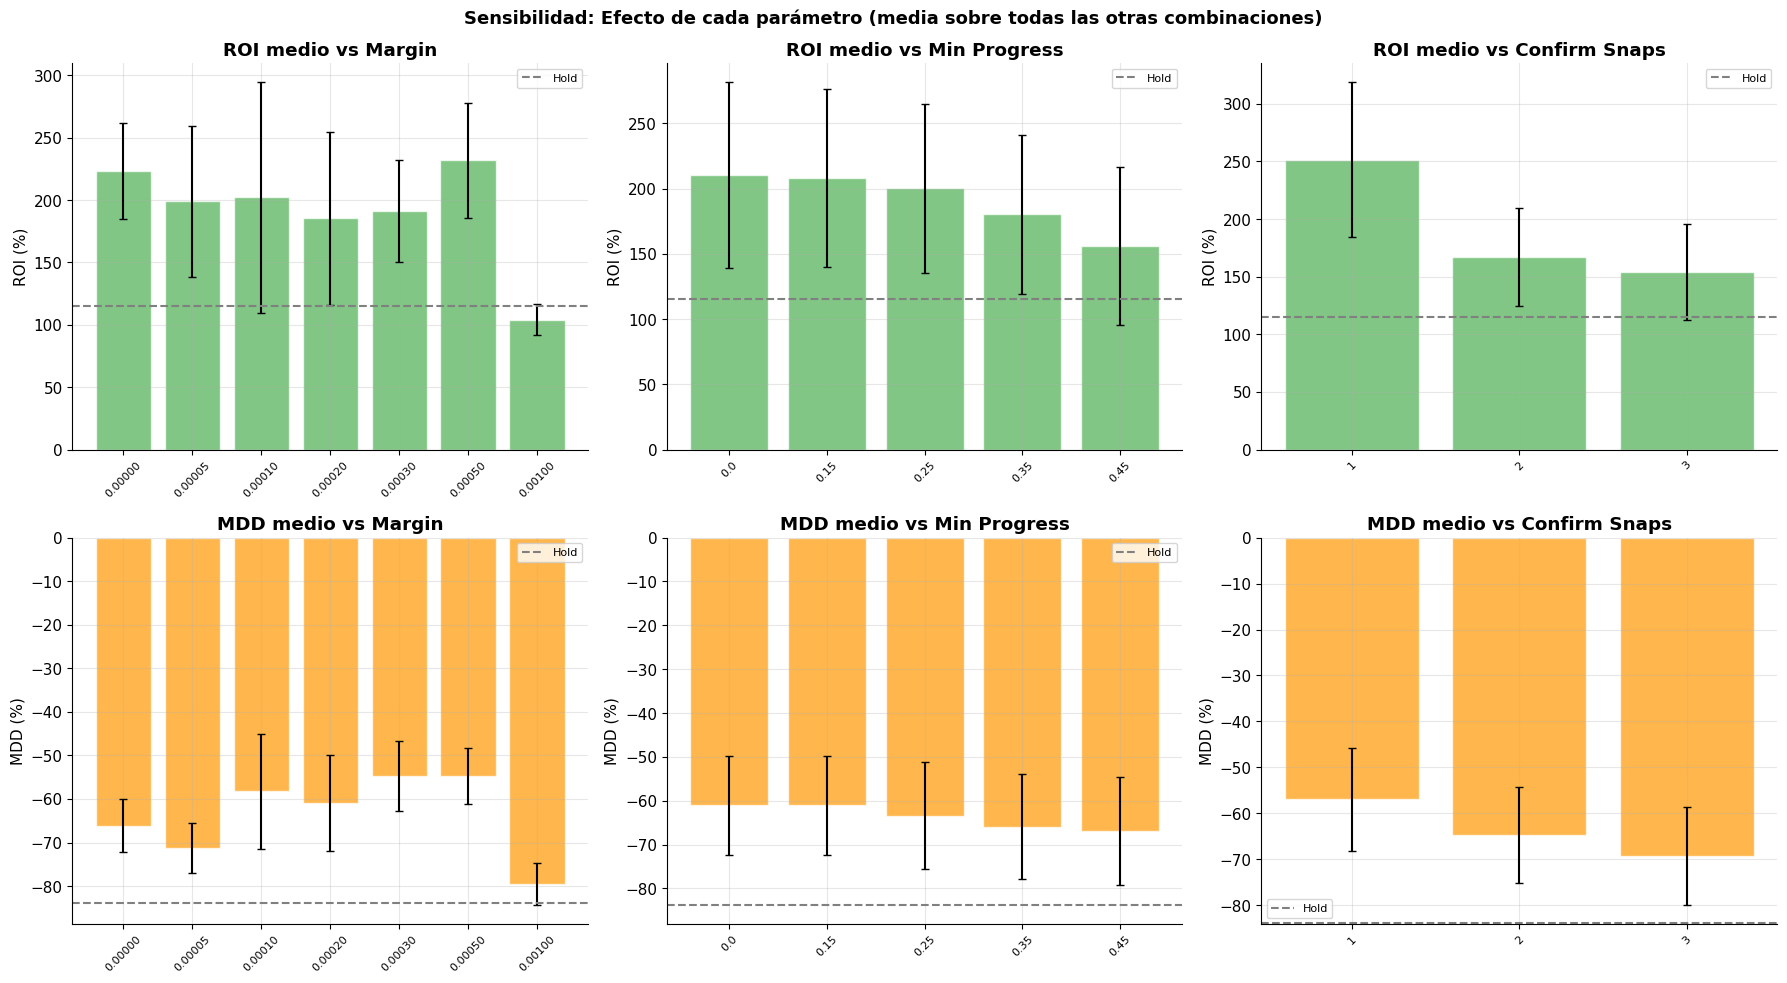

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# 5. SENSIBILIDAD POR PARÁMETRO
# ═══════════════════════════════════════════════════════════════════════
valid = grid_df[grid_df['n'] > 0].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Fila 1: ROI vs cada parámetro ─────────────────────────────────────
for i, (param, label) in enumerate([
    ('margin', 'Margin'),
    ('min_progress', 'Min Progress'),
    ('confirm_snaps', 'Confirm Snaps'),
]):
    ax = axes[0, i]
    grouped = valid.groupby(param).agg(
        roi_mean=('roi', 'mean'), roi_std=('roi', 'std'),
        roi_med=('roi', 'median'),
    ).reset_index()

    ax.bar(range(len(grouped)), grouped['roi_mean'] * 100,
           yerr=grouped['roi_std'] * 100, capsize=3,
           color=['#4CAF50' if v > 0 else '#F44336' for v in grouped['roi_mean']],
           alpha=0.7, edgecolor='white')
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([f"{v:.5f}" if param == 'margin' else f"{v}" for v in grouped[param]],
                        fontsize=8, rotation=45)
    ax.axhline(hold_stats['roi'] * 100, ls='--', color='gray', lw=1.5, label='Hold')
    ax.set_title(f'ROI medio vs {label}', fontweight='bold')
    ax.set_ylabel('ROI (%)')
    ax.legend(fontsize=8)

# ── Fila 2: MDD vs cada parámetro ─────────────────────────────────────
for i, (param, label) in enumerate([
    ('margin', 'Margin'),
    ('min_progress', 'Min Progress'),
    ('confirm_snaps', 'Confirm Snaps'),
]):
    ax = axes[1, i]
    grouped = valid.groupby(param).agg(
        mdd_mean=('mdd', 'mean'), mdd_std=('mdd', 'std'),
    ).reset_index()

    ax.bar(range(len(grouped)), grouped['mdd_mean'] * 100,
           yerr=grouped['mdd_std'] * 100, capsize=3,
           color='#FF9800', alpha=0.7, edgecolor='white')
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([f"{v:.5f}" if param == 'margin' else f"{v}" for v in grouped[param]],
                        fontsize=8, rotation=45)
    ax.axhline(hold_stats['mdd'] * 100, ls='--', color='gray', lw=1.5, label='Hold')
    ax.set_title(f'MDD medio vs {label}', fontweight='bold')
    ax.set_ylabel('MDD (%)')
    ax.legend(fontsize=8)

plt.suptitle('Sensibilidad: Efecto de cada parámetro (media sobre todas las otras combinaciones)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6 · Heatmap 2D: Margin × Min Progress

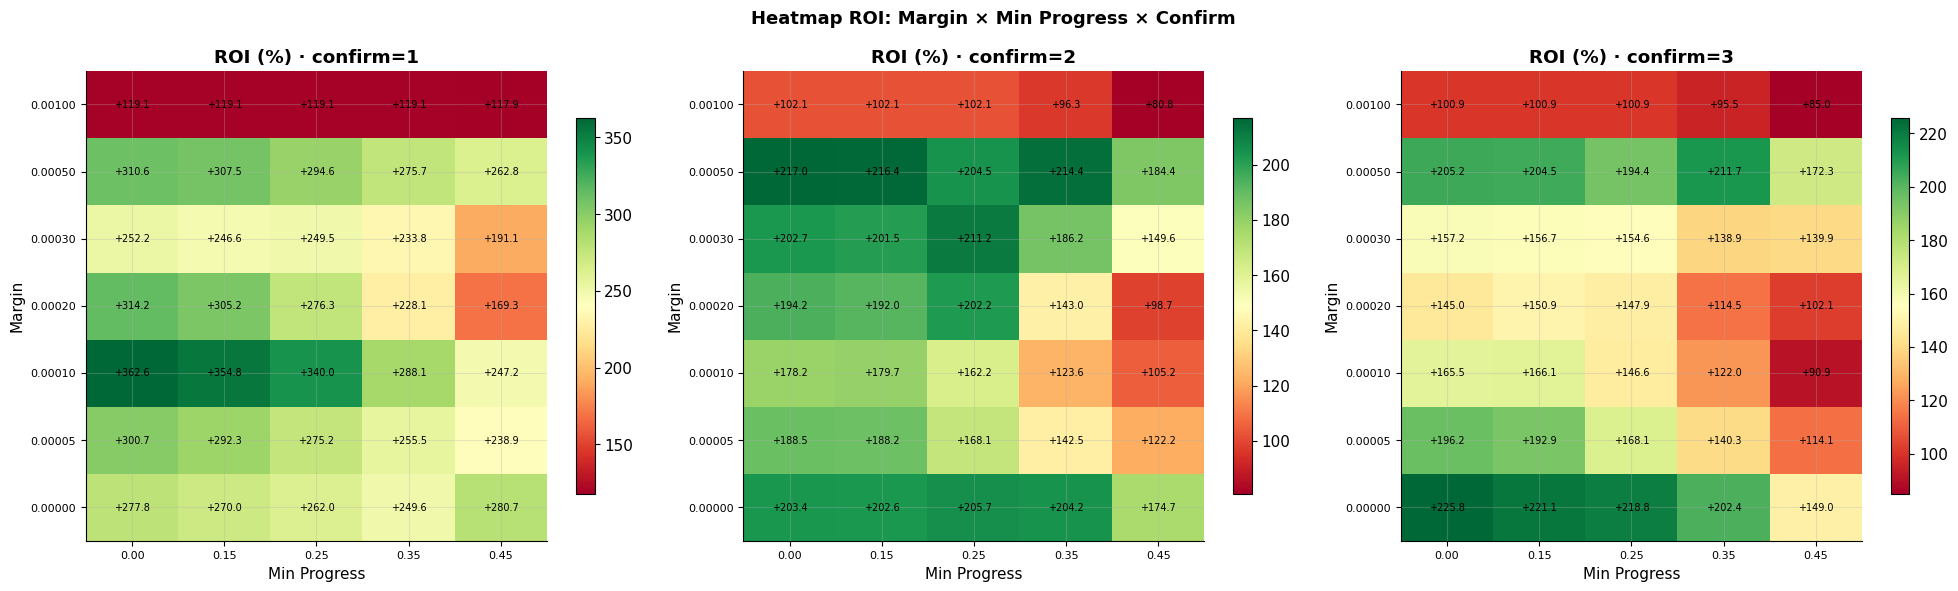

In [7]:
# ═══════════════════════════════════════════════════════════════════════
# 6. HEATMAPS 2D
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for conf_val, ax in zip(GRID['confirm_snaps'], axes):
    subset = valid[valid['confirm_snaps'] == conf_val]
    pivot = subset.pivot_table(index='margin', columns='min_progress',
                                values='roi', aggfunc='mean')

    im = ax.imshow(pivot.values * 100, cmap='RdYlGn', aspect='auto',
                   origin='lower')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{v:.2f}" for v in pivot.columns], fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.5f}" for v in pivot.index], fontsize=8)
    ax.set_xlabel('Min Progress')
    ax.set_ylabel('Margin')
    ax.set_title(f'ROI (%) · confirm={conf_val}', fontweight='bold')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val*100:+.1f}", ha='center', va='center', fontsize=7)

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Heatmap ROI: Margin × Min Progress × Confirm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7 · Equity de Top 3 + Hold

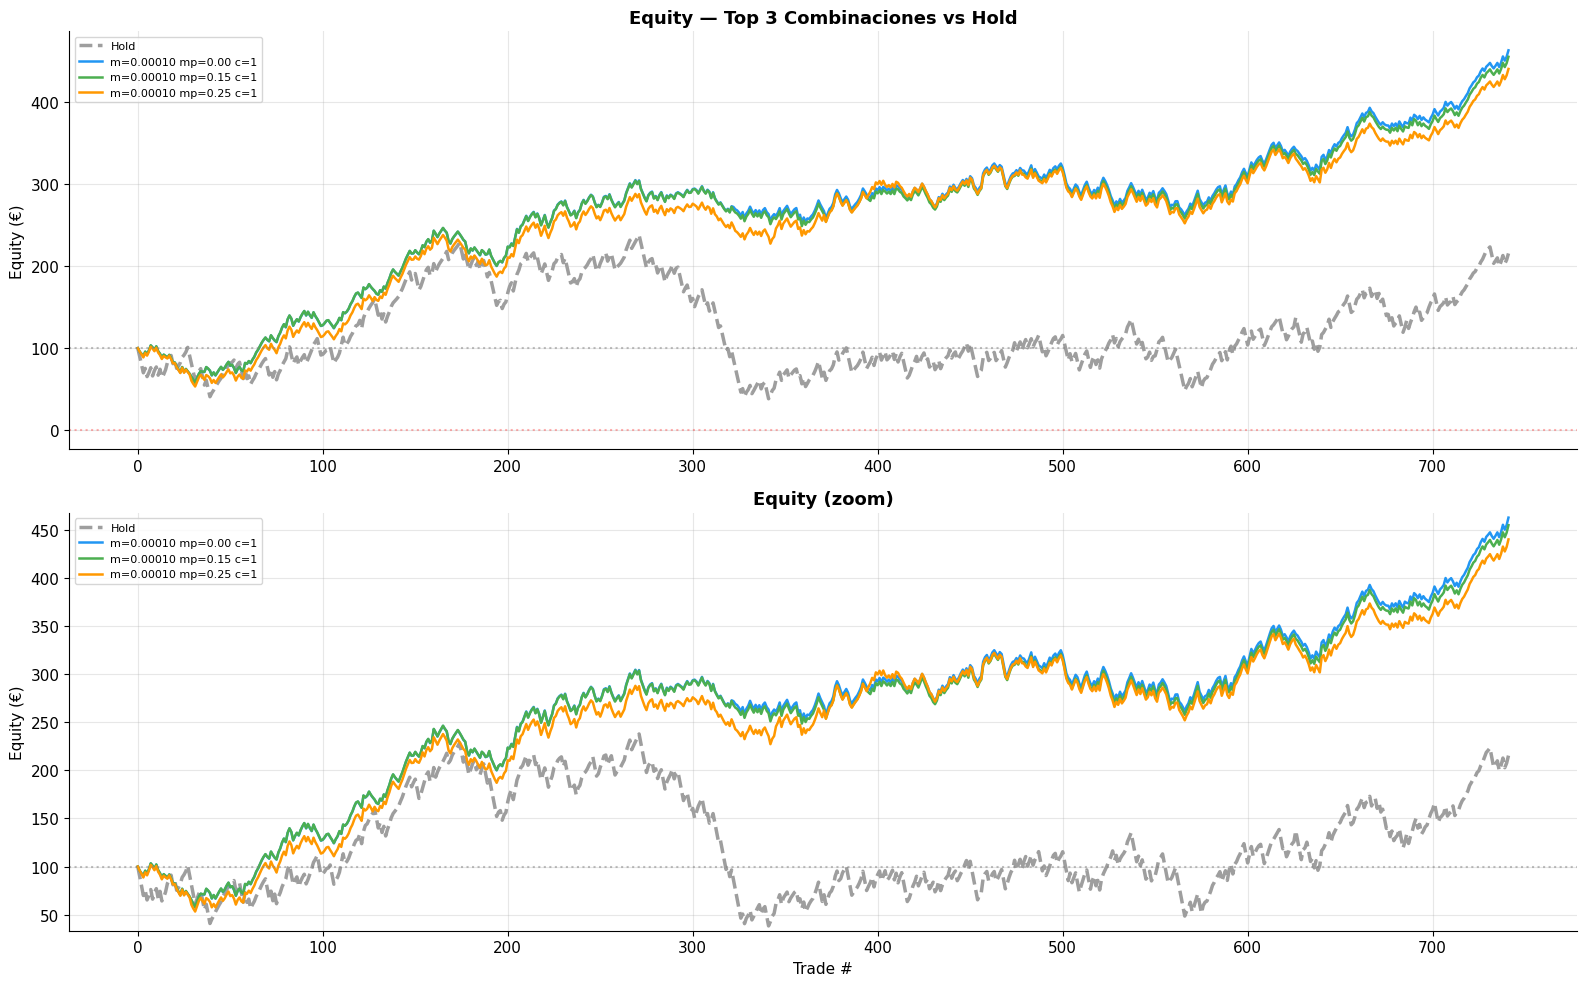

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# 7. EQUITY TOP 3 vs HOLD
# ═══════════════════════════════════════════════════════════════════════
top3_params = top10.head(3)[['margin', 'min_progress', 'confirm_snaps']].values.tolist()

COLORS = ['#9E9E9E', '#2196F3', '#4CAF50', '#FF9800']
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Hold
for ax in axes:
    ax.plot(range(len(eq_hold)), eq_hold.values, label='Hold', color=COLORS[0],
            lw=2.5, ls='--')

# Top 3
top3_logs = {}
top3_equities = {}
for i, (m, mp, cs) in enumerate(top3_params):
    tdf_i, eq_i = run_backtest_mom_reversal(te, CFG, CAL_BASE, m, mp, int(cs))
    label = f"m={m:.5f} mp={mp:.2f} c={int(cs)}"
    top3_logs[label] = tdf_i
    top3_equities[label] = eq_i

    for ax in axes:
        ax.plot(range(len(eq_i)), eq_i.values, label=label, color=COLORS[i+1], lw=1.8)

for ax in axes:
    ax.axhline(CFG['INIT_CAPITAL'], ls=':', color='gray', alpha=0.5)
    ax.axhline(0, ls=':', color='red', alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_title('Equity — Top 3 Combinaciones vs Hold', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Equity (€)')
axes[1].set_ylabel('Equity (€)')
axes[1].set_xlabel('Trade #')

# Zoom segundo panel
all_mins = [eq_hold.values.min()]
all_maxs = [eq_hold.values.max()]
for eq in top3_equities.values():
    all_mins.append(eq.values.min())
    all_maxs.append(eq.values.max())
y_lo = min(all_mins) - 5
y_hi = max(all_maxs) + 5
axes[1].set_ylim(y_lo, y_hi)
axes[1].set_title('Equity (zoom)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

---
## 8 · Análisis de Exits del Top 1

In [9]:
# ═══════════════════════════════════════════════════════════════════════
# 8. ANÁLISIS DETALLADO — TOP 1
# ═══════════════════════════════════════════════════════════════════════
best_row = top10.iloc[0]
best_m, best_mp, best_cs = best_row['margin'], best_row['min_progress'], int(best_row['confirm_snaps'])
best_label = f"m={best_m:.5f} mp={best_mp:.2f} c={best_cs}"

tdf_best = top3_logs.get(best_label)
if tdf_best is None:
    tdf_best, _ = run_backtest_mom_reversal(te, CFG, CAL_BASE, best_m, best_mp, best_cs)

print(f"MEJOR COMBINACIÓN: margin={best_m}  min_progress={best_mp}  confirm={best_cs}")
print(f"═" * 70)

exits = tdf_best[tdf_best['exit_type'] == 'EARLY_EXIT']
holds = tdf_best[tdf_best['exit_type'] == 'RESOLUTION']

print(f"  Total trades:    {len(tdf_best)}")
print(f"  Early exits:     {len(exits)} ({len(exits)/len(tdf_best):.0%})")
print(f"  Hold to res:     {len(holds)} ({len(holds)/len(tdf_best):.0%})")
print(f"  PnL total:       {tdf_best['pnl'].sum():+.2f}€")
print(f"  ROI:             {tdf_best['pnl'].sum()/CFG['INIT_CAPITAL']:+.2%}")

if len(exits) > 0:
    print(f"\n  EARLY EXITS:")
    print(f"    PnL total:     {exits['pnl'].sum():+.2f}€")
    print(f"    PnL medio:     {exits['pnl'].mean():+.4f}€")
    print(f"    % PnL > 0:     {(exits['pnl'] > 0).mean():.1%}")

    saved = exits[exits['pnl'] > exits['pnl_at_resolution']]
    worse = exits[exits['pnl'] <= exits['pnl_at_resolution']]
    print(f"\n    Exits que MEJORARON vs hold: {len(saved)}/{len(exits)}")
    if len(saved) > 0:
        delta = saved['pnl'].sum() - saved['pnl_at_resolution'].sum()
        print(f"      Ahorro: {delta:+.2f}€")
    print(f"    Exits que EMPEORARON vs hold: {len(worse)}/{len(exits)}")
    if len(worse) > 0:
        delta = worse['pnl'].sum() - worse['pnl_at_resolution'].sum()
        print(f"      Coste: {delta:+.2f}€")

    # ¿A qué progress salen?
    print(f"\n    Exit progress medio: {exits['exit_progress'].mean():.1%}")
    print(f"    Exit progress min:   {exits['exit_progress'].min():.1%}")
    print(f"    Exit progress max:   {exits['exit_progress'].max():.1%}")

if len(holds) > 0:
    print(f"\n  HOLD TO RESOLUTION:")
    print(f"    PnL total:     {holds['pnl'].sum():+.2f}€")
    print(f"    WR:            {(holds['pnl'] > 0).mean():.1%}")

MEJOR COMBINACIÓN: margin=0.0001  min_progress=0.0  confirm=1
══════════════════════════════════════════════════════════════════════
  Total trades:    741
  Early exits:     350 (47%)
  Hold to res:     391 (53%)
  PnL total:       +362.62€
  ROI:             +362.62%

  EARLY EXITS:
    PnL total:     -1299.61€
    PnL medio:     -3.7132€
    % PnL > 0:     2.9%

    Exits que MEJORARON vs hold: 219/350
      Ahorro: +1323.28€
    Exits que EMPEORARON vs hold: 131/350
      Coste: -1075.97€

    Exit progress medio: 47.9%
    Exit progress min:   11.0%
    Exit progress max:   99.7%

  HOLD TO RESOLUTION:
    PnL total:     +1662.22€
    WR:            97.2%


---
## 9 · Monte Carlo — Top 3

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# 9. MONTE CARLO
# ═══════════════════════════════════════════════════════════════════════
N_MC = 30
TEST_PCT = 0.45
rng = np.random.RandomState(SEED)
all_markets = df['market_slug'].unique().tolist()
n_test_mc = int(len(all_markets) * TEST_PCT)

# Top 3 + Hold
mc_configs = [('Hold', 999, 0, 1)]
for i, (m, mp, cs) in enumerate(top3_params):
    mc_configs.append((f"Top{i+1}", m, mp, int(cs)))

mc_all = {name: [] for name, *_ in mc_configs}

print(f"Monte Carlo: {N_MC} iters, {n_test_mc} mercados/iter")
for name, m, mp, cs in mc_configs:
    print(f"  {name}: margin={m} min_prog={mp} confirm={cs}")

for it in range(N_MC):
    shuffled = rng.permutation(all_markets)
    mc_test = df[df['market_slug'].isin(shuffled[:n_test_mc])].copy()

    for name, m, mp, cs in mc_configs:
        tdf, eq_s = run_backtest_mom_reversal(mc_test, CFG, CAL_BASE, m, mp, cs)
        if tdf.empty:
            mc_all[name].append(dict(n=0, pnl=0, roi=0, mdd=0, sharpe=0))
            continue
        pa = tdf['pnl'].values
        eq = eq_s.values
        rm = np.maximum.accumulate(eq)
        mc_all[name].append(dict(
            n=len(tdf), pnl=pa.sum(), roi=pa.sum()/CFG['INIT_CAPITAL'],
            mdd=((eq-rm)/rm).min(),
            sharpe=pa.mean()/(pa.std()+1e-9)*np.sqrt(len(tdf)),
        ))

# Resumen
print(f"\n{'═' * 80}")
print(f"  MONTE CARLO — RESUMEN ({N_MC} iters)")
print(f"{'═' * 80}")

mc_summary = {}
for name, *_ in mc_configs:
    mc_df = pd.DataFrame(mc_all[name])
    mc_v = mc_df[mc_df['n'] > 0]
    mc_summary[name] = mc_v
    if mc_v.empty:
        continue
    print(f"\n  ── {name} ──")
    for col, label, fmt in [
        ('roi', 'ROI', '+.2%'), ('pnl', 'PnL(€)', '+.2f'),
        ('sharpe', 'Sharpe', '.2f'), ('mdd', 'MDD', '.2%'),
    ]:
        v = mc_v[col].dropna()
        print(f"    {label:<10} media={v.mean():{fmt}}  p10={v.quantile(0.10):{fmt}}  "
              f"p90={v.quantile(0.90):{fmt}}")
    print(f"    %ROI>0: {(mc_v['roi']>0).mean():.0%}  "
          f"%MDD>-50%: {(mc_v['mdd']>-0.50).mean():.0%}")

Monte Carlo: 30 iters, 802 mercados/iter
  Hold: margin=999 min_prog=0 confirm=1
  Top1: margin=0.0001 min_prog=0.0 confirm=1
  Top2: margin=0.0001 min_prog=0.15 confirm=1
  Top3: margin=0.0001 min_prog=0.25 confirm=1

════════════════════════════════════════════════════════════════════════════════
  MONTE CARLO — RESUMEN (30 iters)
════════════════════════════════════════════════════════════════════════════════

  ── Hold ──
    ROI        media=+104.01%  p10=-78.84%  p90=+280.82%
    PnL(€)     media=+104.01  p10=-78.84  p90=+280.82
    Sharpe     media=0.55  p10=-0.41  p90=1.52
    MDD        media=-95.21%  p10=-147.18%  p90=-56.03%
    %ROI>0: 77%  %MDD>-50%: 7%

  ── Top1 ──
    ROI        media=+382.81%  p10=+285.29%  p90=+492.05%
    PnL(€)     media=+382.81  p10=+285.29  p90=+492.05
    Sharpe     media=2.87  p10=2.13  p90=3.69
    MDD        media=-31.11%  p10=-39.97%  p90=-20.65%
    %ROI>0: 100%  %MDD>-50%: 100%

  ── Top2 ──
    ROI        media=+376.85%  p10=+278.20%  p90=

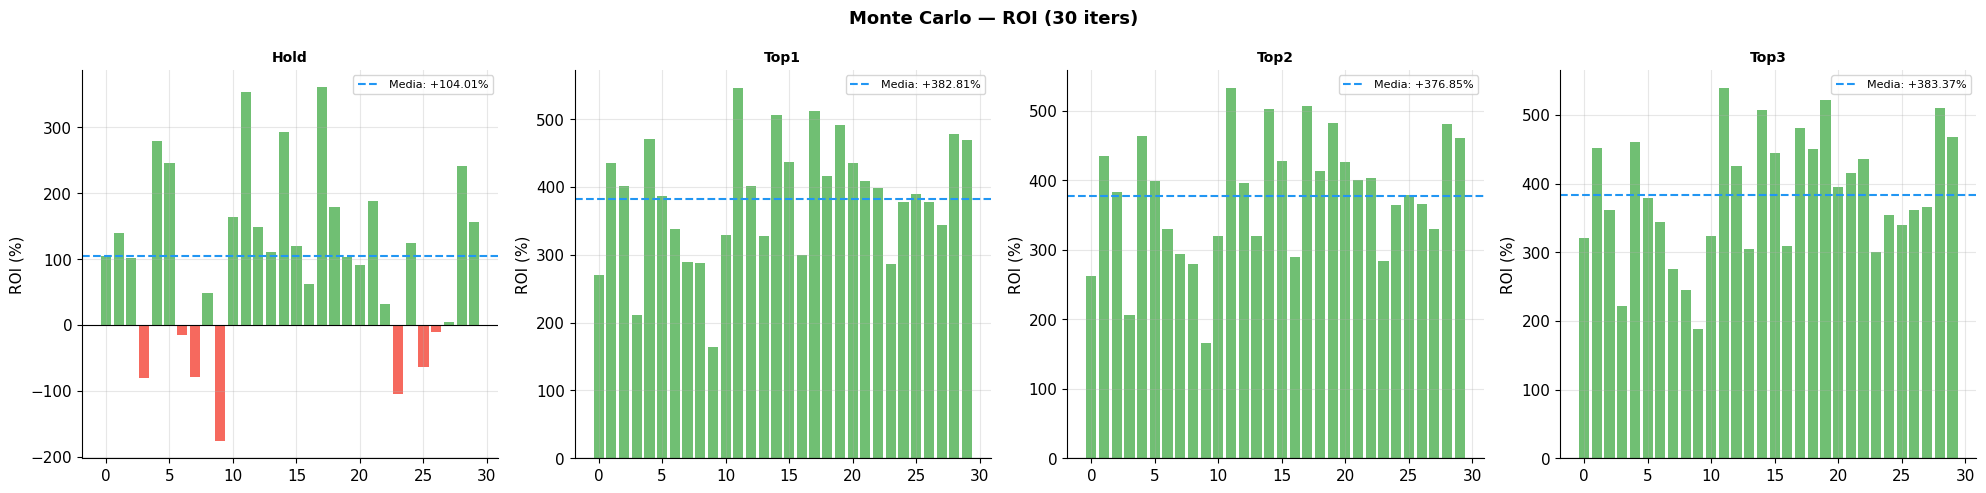

In [11]:
# Monte Carlo gráficos
fig, axes = plt.subplots(1, len(mc_configs), figsize=(5*len(mc_configs), 5))

for i, (name, *_) in enumerate(mc_configs):
    ax = axes[i]
    mc_v = mc_summary.get(name, pd.DataFrame())
    if mc_v.empty:
        continue
    c = ['#4CAF50' if v > 0 else '#F44336' for v in mc_v['roi']]
    ax.bar(range(len(mc_v)), mc_v['roi'].values*100, color=c, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(mc_v['roi'].mean()*100, ls='--', color='#2196F3', lw=1.5,
               label=f"Media: {mc_v['roi'].mean():+.2%}")
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_ylabel('ROI (%)')
    ax.legend(fontsize=8)

plt.suptitle(f'Monte Carlo — ROI ({N_MC} iters)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10 · Veredicto

In [12]:
# ═══════════════════════════════════════════════════════════════════════
# 10. VEREDICTO
# ═══════════════════════════════════════════════════════════════════════
D = '═' * 70
print(D)
print('  VEREDICTO — OPTIMIZACIÓN MOM_REVERSAL EXIT')
print(D)

print(f"\n  Grid search: {len(combos)} combinaciones evaluadas")
print(f"  Mejor combinación (test set):")
print(f"    margin         = {best_m}")
print(f"    min_progress   = {best_mp}")
print(f"    confirm_snaps  = {best_cs}")
print(f"    ROI            = {best_row['roi']:+.2%}")
print(f"    MDD            = {best_row['mdd']:.1%}")
print(f"    Sharpe         = {best_row['sharpe']:.2f}")

d_roi = best_row['roi'] - hold_stats['roi']
d_mdd = best_row['mdd'] - hold_stats['mdd']
print(f"\n  vs Hold:")
print(f"    ΔROI = {d_roi:+.2%}")
print(f"    ΔMDD = {d_mdd:+.1%} ({'mejor' if d_mdd > 0 else 'peor'})")

# MC del top 1
mc_top1 = mc_summary.get('Top1', pd.DataFrame())
mc_hold = mc_summary.get('Hold', pd.DataFrame())
if not mc_top1.empty and not mc_hold.empty:
    print(f"\n  Monte Carlo ({N_MC} iters):")
    print(f"    {'':>15} {'Hold':>12} {'Top1':>12}")
    print(f"    {'ROI medio':<15} {mc_hold['roi'].mean():>+11.2%} {mc_top1['roi'].mean():>+11.2%}")
    print(f"    {'MDD medio':<15} {mc_hold['mdd'].mean():>+11.1%} {mc_top1['mdd'].mean():>+11.1%}")
    print(f"    {'%ROI>0':<15} {(mc_hold['roi']>0).mean():>11.0%} {(mc_top1['roi']>0).mean():>11.0%}")
    print(f"    {'Sharpe medio':<15} {mc_hold['sharpe'].mean():>11.2f} {mc_top1['sharpe'].mean():>11.2f}")

print(f"\n  PARÁMETROS PARA PRODUCCIÓN (signal_engine.py):")
print(f"    MOM_REVERSAL_MARGIN    = {best_m}")
print(f"    MOM_REVERSAL_MIN_PROG  = {best_mp}")
print(f"    MOM_REVERSAL_CONFIRM   = {best_cs}")

print(f"\n  ⚠️  NOTA: los parámetros están optimizados sobre ~4 días de datos.")
print(f"     Con más datos, re-ejecutar este notebook para reoptimizar.")
print(f"     Considerar usar los percentiles 25-75 del grid (no solo el top 1)")
print(f"     para elegir parámetros robustos, no solo los del pico.")
print(D)

══════════════════════════════════════════════════════════════════════
  VEREDICTO — OPTIMIZACIÓN MOM_REVERSAL EXIT
══════════════════════════════════════════════════════════════════════

  Grid search: 105 combinaciones evaluadas
  Mejor combinación (test set):
    margin         = 0.0001
    min_progress   = 0.0
    confirm_snaps  = 1
    ROI            = +362.62%
    MDD            = -44.2%
    Sharpe         = 2.78

  vs Hold:
    ΔROI = +247.31%
    ΔMDD = +39.6% (mejor)

  Monte Carlo (30 iters):
                            Hold         Top1
    ROI medio          +104.01%    +382.81%
    MDD medio            -95.2%      -31.1%
    %ROI>0                  77%        100%
    Sharpe medio           0.55        2.87

  PARÁMETROS PARA PRODUCCIÓN (signal_engine.py):
    MOM_REVERSAL_MARGIN    = 0.0001
    MOM_REVERSAL_MIN_PROG  = 0.0
    MOM_REVERSAL_CONFIRM   = 1

  ⚠️  NOTA: los parámetros están optimizados sobre ~4 días de datos.
     Con más datos, re-ejecutar este notebook para